# TODO

jobs STARTED IN OR AFTER year of graduation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

plt.style.use("ggplot")

output = "output/csv/"
input = "input/"
figures = "figures/"
uk = ["England", "Scotland", "Wales", "Northern Ireland"]

papers = pd.read_excel(f"{input}students.xlsx", sheet_name="Papers").drop_duplicates(
    subset=["DOI"], keep="first"
)

papers_dropped = papers.drop_duplicates(subset='Name')

this_year = datetime.now().year

papers_all = pd.read_csv(f"{output}papers_all.csv")


students = pd.read_excel(f"{input}students.xlsx", sheet_name="Students")
students = students[students.Year != 2020]
students['yrs_since_graduation'] = this_year - students['Thesis Year']
students['yrs_since_starting'] = this_year - papers['Year']
students_merge = pd.merge(students, papers_dropped, how='left', on='Name')

jobs = pd.read_excel(f"{input}students.xlsx", sheet_name="Jobs")


to_exclude = [0, "0", np.nan, "nan", "None", "none", "", "Not Found", "Error"]

## Papers and publications
### Graduates' publications since starting with the DTC

A large proportion of the publication history was collected prior to my joining, using (at least mostly, I presume) methodology as outlined by Hector in his onboarding. This entailed looking up the graduate's name on Scopus and manually exporting their publication history as a spreadsheet which was then manually appended onto the master spreadsheet.

This has the advantage of accuracy (see discussion of manual LinkedIn scraping) but is time consuming, so I have opted to use an API instead. I have used [OpenAlex](https://openalex.org/): this is open source (unlike alternatives such as [SemanticScholar](https://www.semanticscholar.org/), which is AI-driven and I will use to verify, now that they responded to me!, and Elsevier's own proprietary API) and free (another win over Elsevier).

Methodology:
1. API search for each name in the alumni database. Retrieve the corresponding ORCID for the closest match, as well as said closest match's listed name.
2. Using these ORCIDs, perform an API search to find the corresponding OpenAlex 'author object' and its associated papers.
3. Where the name listed in the alumni database doesn't match the name corresponding to the ORCID found in the API search, manually check the ORCID/OpenAlex record for the person found. In some cases it's the same person under a different name; where this is NOT the case, exclude all papers with this ORCID.

I also performed random checks on the ORCIDs where there was a name match (ie those that were not auto-flagged as suspicious during step 3) to check that they are correct.

This code can be rerun any time, including with corrected ORCIDs need be.

To start with, we can look at how many papers each alumnus published. Of course this is a metric in which there will be a few extreme outlisers.

### How many papers did students publish?

Some students have published a LOT of papers. Descriptive statistics of how many papers each students published are down below.

Descriptive statistics of papers per student


,papers
count,889.000000
mean,15.753656
std,16.292617
min,1.000000
25%,5.000000
50%,12.000000
75%,23.000000
max,180.000000


We will threshold at two standard deviations above the mean: 48.338890567526676


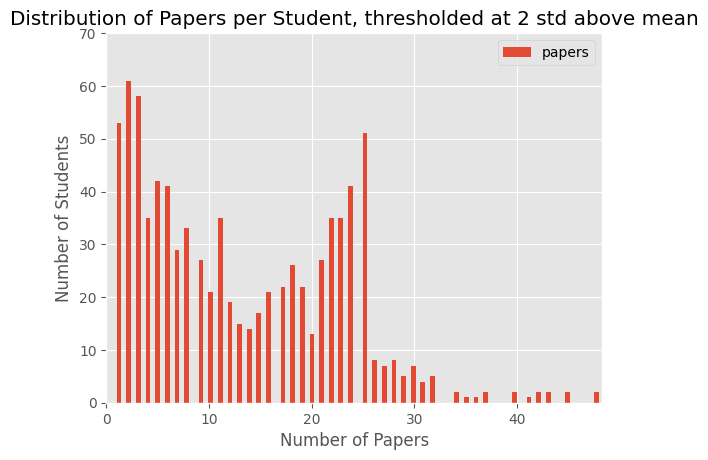

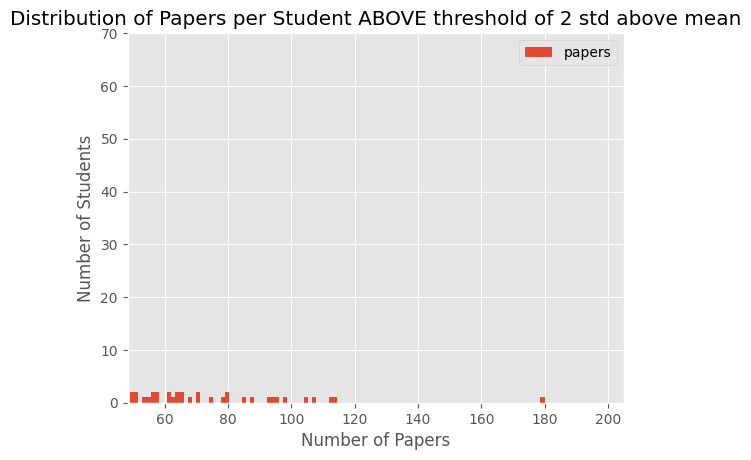

In [2]:
paper_counts = papers["Name"].value_counts().reset_index()
paper_counts.columns = ["Name", "papers"]
paper_counts = paper_counts.sort_values("papers", ascending=False)
paper_counts["papers"] = paper_counts["papers"].astype(float)

print("Descriptive statistics of papers per student")
desc = paper_counts["papers"].describe().to_frame()
display(desc)

mn = desc.loc["mean", "papers"]
std = desc.loc["std", "papers"]

thresh = mn + 2 * std
print(f"We will threshold at two standard deviations above the mean: {thresh}")

paper_counts[paper_counts.papers < thresh].plot(kind="hist", bins=100)
plt.title("Distribution of Papers per Student, thresholded at 2 std above mean")
plt.xlabel("Number of Papers")
plt.ylabel("Number of Students")
plt.ylim(0, 70)
plt.xlim(0, thresh)
plt.savefig(f"{figures}papers_per_student_hist.png")
plt.show()

paper_counts[paper_counts.papers > thresh].plot(kind="hist", bins=100)
plt.title("Distribution of Papers per Student ABOVE threshold of 2 std above mean")
plt.xlabel("Number of Papers")
plt.ylabel("Number of Students")
plt.ylim(0, 70)
plt.xlim(thresh, 205)
plt.savefig(f"{figures}papers_per_student_hist.png")
plt.show()

51
Descriptive statistics of papers/yr per student


,papers_time
count,838.000000
mean,1.390804
std,1.112274
min,0.043478
25%,0.500000
50%,1.181818
75%,2.000000
max,8.181818


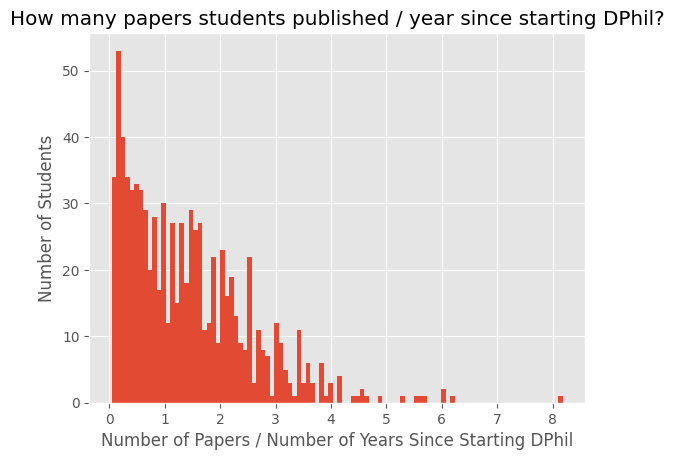

In [3]:
# numer of papers / number of years since starting
missing_names = []
current_year = datetime.now().year
num_papers_stand = papers["Name"].value_counts().reset_index()
num_papers_stand["Year"] = None
num_papers_stand["yr_since"] = None
for i, row in num_papers_stand.iterrows():
    name = row["Name"]
    try:
        year = students.loc[students["Name"] == name, "Year"].values[0]
        
        num_papers_stand.loc[i, "Year"] = year
        num_papers_stand.loc[i, "yr_since"] = current_year - year
    except IndexError:
        missing_names.append(name)
print(len(missing_names))
num_papers_stand = num_papers_stand.loc[num_papers_stand["Year"] != 0]
num_papers_stand["papers_time"] = (
    num_papers_stand["count"] / num_papers_stand["yr_since"]
)

print("Descriptive statistics of papers/yr per student")
num_papers_stand["papers_time"] = num_papers_stand["papers_time"].astype(float)
desc = num_papers_stand["papers_time"].describe().to_frame()
display(desc)

num_papers_stand["papers_time"].plot(kind="hist", bins=100)
plt.title("How many papers students published / year since starting DPhil?")
plt.xlabel("Number of Papers / Number of Years Since Starting DPhil")
plt.ylabel("Number of Students")
# plt.ylim(0, 120)
plt.show()

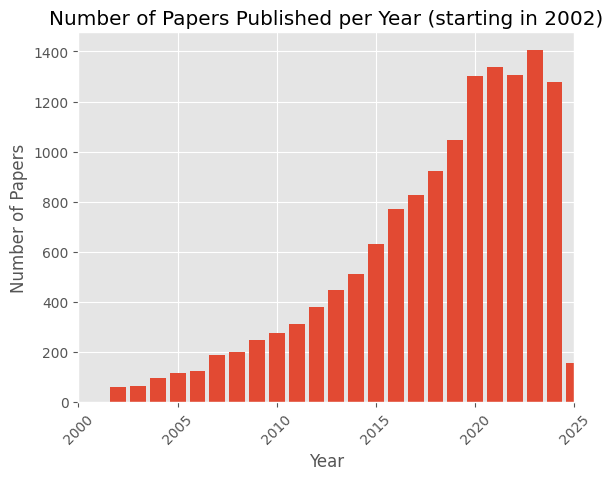

In [4]:
# bar chart of publication year
papers["Year"] = papers["Year"].astype(float)
# papers['years'] = papers['years'].astype(int)
papers_per_year = papers["Year"].value_counts().reset_index()
papers_per_year.columns = ["Year", "papers"]
papers_per_year = papers_per_year.sort_values("Year")
plt.bar(papers_per_year["Year"], papers_per_year["papers"])
# andgle the x-axis labels
plt.xticks(rotation=45)
plt.title("Number of Papers Published per Year (starting in 2002)")
plt.xlim(2000, 2025)
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.savefig(f"{figures}papers_per_year.png")
plt.show()

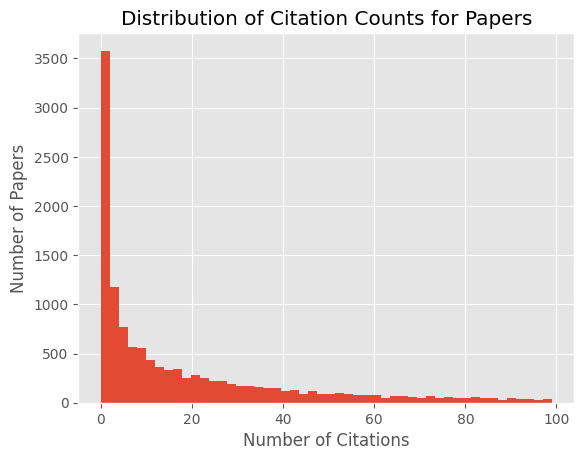

In [5]:
# histogram of citation count
papers["Citation Count"] = papers["Citation Count"].astype(float)
citation_counts = papers[papers["Citation Count"] < 100]
# .value_counts().reset_index()
citation_counts["Citation Count"].plot(kind="hist", bins=50)
plt.title("Distribution of Citation Counts for Papers")
plt.xlabel("Number of Citations")
plt.ylabel("Number of Papers")
plt.show()

/var/folders/zk/7wt7hny90bjd8lg6jxjt4fkc0000gr/T/ipykernel_35315/1845696349.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.6666666666666665' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  citation_counts.loc[i, "mean_citation"] = citations / n_papers


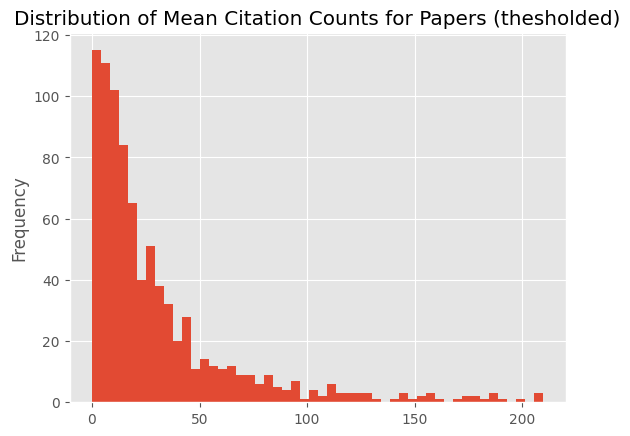

In [6]:
# distribution of mean citation count per paper for each student
citation_counts = pd.DataFrame({"Name": papers.Name.unique()})
citation_counts['Citation Count'] = 0
citation_counts["papers"] = 0
citation_counts["mean_citation"] = 0
for i, row in citation_counts.iterrows():
    name = row["Name"]
    n_papers = papers[papers.Name == name].shape[0]
    citations = papers[papers.Name == name]["Citation Count"].sum()
    citation_counts.loc[i, "papers"] = n_papers
    citation_counts.loc[i, "Citation Count"] = citations
    if n_papers > 0:
        citation_counts.loc[i, "mean_citation"] = citations / n_papers
    else:
        citation_counts.loc[i, "mean_citation"] = 0
citation_counts = citation_counts[citation_counts["papers"] > 0]
citation_counts = citation_counts[citation_counts["Citation Count"] > 0]

mean = citation_counts["mean_citation"].mean()
std = citation_counts["mean_citation"].std()
citation_counts = citation_counts[citation_counts["mean_citation"] < mean + 2 * std]

citation_counts["mean_citation"].plot(kind="hist", bins=50)
    
plt.title("Distribution of Mean Citation Counts for Papers (thesholded)")
plt.show()

In [7]:
students_merge

,ID,Name,Year_x,Course,Job Title,Sector,Continent,Country,City,UGDegree,...,yrs_since_graduation,yrs_since_starting,DOI,Title,Journal,Year_y,Citation Count,orcid,i10,h_index
0,LSI20024,Daniel Gallichan,2002,LSI,"University Lecturer, Cardiff, Nov 2016 - Present",Academia,Europe,Wales,Cardiff,Physics with a European Language,...,18.0,16.0,10.1002/mrm.21039,Bayesian inference of hemodynamic changes in f...,Magnetic Resonance in Medicine,2006.0,37.0,NaN,NaN,NaN
1,LSI20021,Danny Axford,2002,LSI,"Senior Beamline Scientist (Life Science), Diam...",Industry (Other),Europe,England,Oxford,NaN,...,18.0,16.0,10.1039/b417712f,Molecular bioelectronics,Journal of Materials Chemistry,2005.0,97.0,https://orcid.org/0000-0001-7694-8525,46,28
2,LSI20022,Ella Chase (Adlen),2002,LSI,"Chief of Staff, Genomics Plc, Mar 2020 - Present",Industry (Health),Europe,England,Oxford,Human Sciences,...,19.0,10.0,10.1186/1471-2148-13-110,Hypervariable antigen genes in malaria have an...,BMC Evolutionary Biology,2013.0,13.0,https://orcid.org/0000-0003-0626-8246,4,4
3,LSI20029,James Southern,2002,LSI,"Principle Applications Engineer, Hewlett-Packa...",Software,Europe,England,Warfield,Mathematical Sciences,...,19.0,10.0,10.1098/rsta.2008.0308,CHASTE: incorporating a novel multi-scale spat...,PHILOSOPHICAL TRANSACTIONS OF THE ROYAL SOCIET...,2009.0,29.0,https://orcid.org/0000-0002-6385-3479,Error,Error
4,LSI20028,Kieran Smallbone,2002,LSI,"Cheese shop and post-office proprietor, NA, NA",Other,Europe,England,Chinley,Mathematics and Computer Science,...,19.0,10.0,10.1016/j.jtbi.2005.02.001,The role of acidity in solid tumour growth and...,Journal of Theoretical Biology,2005.0,150.0,https://orcid.org/0000-0003-2815-7045,39,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,NERC20191020,Tim Hempel,2019,NERC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1033,SABS2019956,Tobias Hegelund Olsen,2019,SABS,"Scientist II (Computational Protein Design), M...",Industry (Pharma),North America,United States,Cambridge MA,Biotechnology,...,2.0,18.0,10.1038/s41598-019-50932-4,TCRpMHCmodels: Structural modelling of TCR-pMH...,Scientific Reports,2019.0,51.0,https://orcid.org/0000-0002-6348-4650,13,11
1034,NERC20191024,William Langdon,2019,NERC,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,17.0,10.1101/2022.06.24.497466,Codistribution as an indicator of whole metaco...,bioRxiv (Cold Spring Harbor Laboratory),2022.0,0.0,https://orcid.org/0000-0001-8695-403X,0,1
1035,DTP2019986,Xenia Karlsson,2019,DTP,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,17.0,10.1371/journal.pgen.1007039,The creation and selection of mutations resist...,PLoS Genetics,2017.0,297.0,https://orcid.org/0000-0001-5026-0693,5,5


Index(['Name', 'DOI', 'Title', 'Journal', 'Year', 'Citation Count', 'orcid',
       'i10', 'h_index'],
      dtype='object')


/var/folders/zk/7wt7hny90bjd8lg6jxjt4fkc0000gr/T/ipykernel_35315/123663848.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  indices = indices.replace({"Error": np.nan, "Not Found": np.nan})


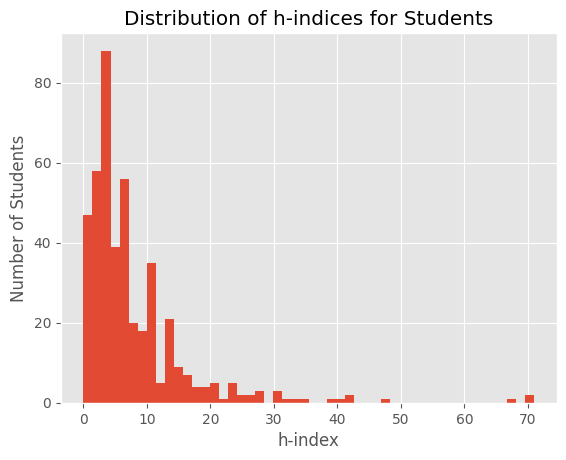

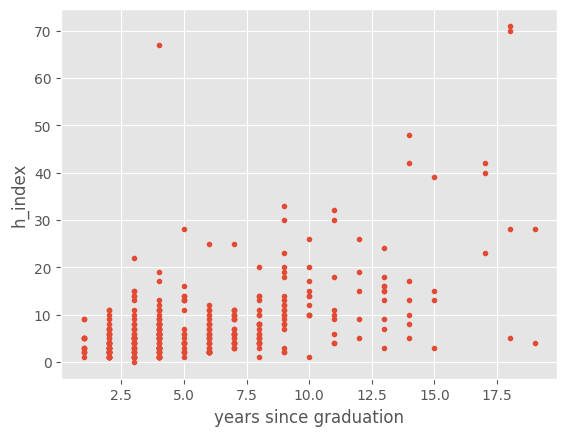

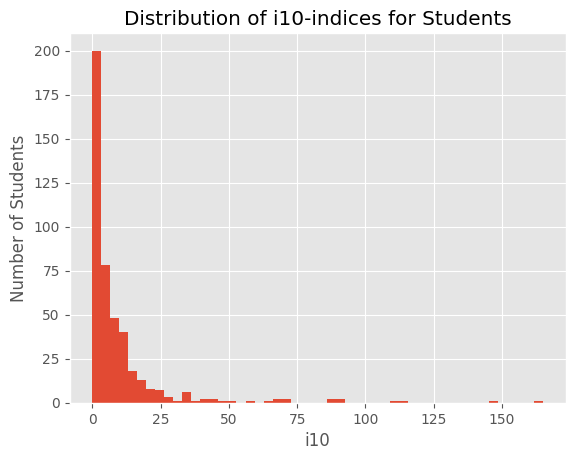

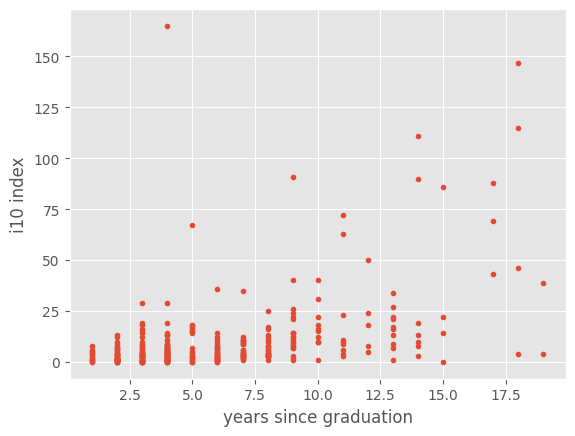

In [8]:
# distribution of h- and i-10 indices
print(papers.columns)
indices = papers.drop_duplicates(subset=["Name", "h_index", "i10"], keep="first")
indices = indices.replace({"Error": np.nan, "Not Found": np.nan})
indices["h_index"] = indices["h_index"].astype(float)
indices["i10"] = indices["i10"].astype(float)
indices["h_index"].plot(kind="hist", bins=50)
plt.title("Distribution of h-indices for Students")
plt.xlabel("h-index")
plt.ylabel("Number of Students")
plt.show()

h_indices = students_merge.dropna(subset=["h_index"])
h_indices = h_indices[h_indices["h_index"] != "Error"]
plt.plot(h_indices.yrs_since_graduation, h_indices.h_index, '.')
plt.xlabel('years since graduation')
plt.ylabel('h_index')
plt.show()

# h_indices = students_merge.dropna(subset=["h_index"])
# h_indices = h_indices[h_indices["h_index"] != "Error"]
# plt.plot(h_indices.yrs_since_starting, h_indices.h_index, '.')
# plt.xlabel('years since starting at DTC')
# plt.ylabel('h_index')
# plt.show()

indices["i10"].plot(kind="hist", bins=50)
plt.title("Distribution of i10-indices for Students")
plt.xlabel("i10")
plt.ylabel("Number of Students")
plt.show()

i10_indices = students_merge.dropna(subset=["i10"])
i10_indices = i10_indices[i10_indices["i10"] != "Error"]
plt.plot(i10_indices.yrs_since_graduation, i10_indices.i10, '.')
plt.xlabel('years since graduation')
plt.ylabel('i10 index')
plt.show()

# i10_indices = students_merge.dropna(subset=["i10"])
# i10_indices = i10_indices[i10_indices["i10"] != "Error"]
# plt.plot(i10_indices.yrs_since_starting, i10_indices.i10, '.')
# plt.xlabel('years since starting at DTC')
# plt.ylabel('i10 index')
# plt.show()

### Journal level

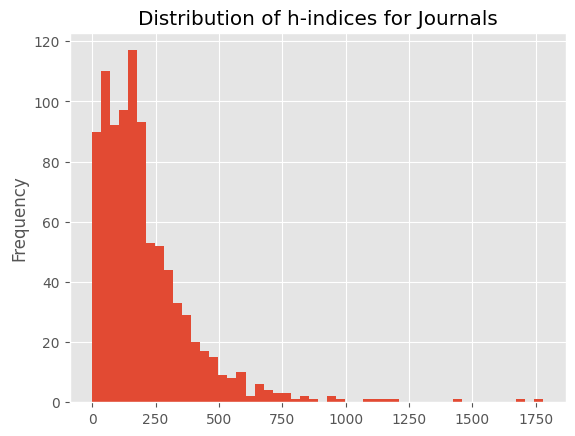

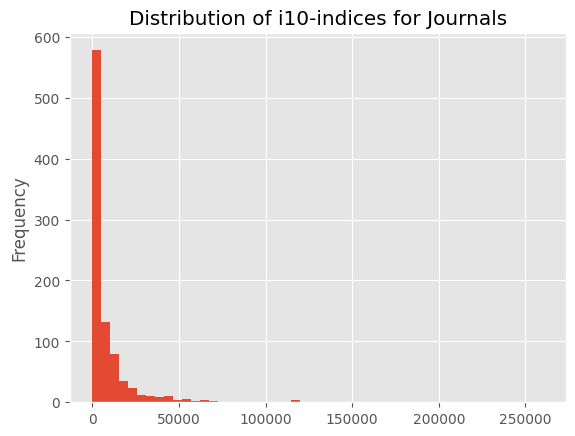

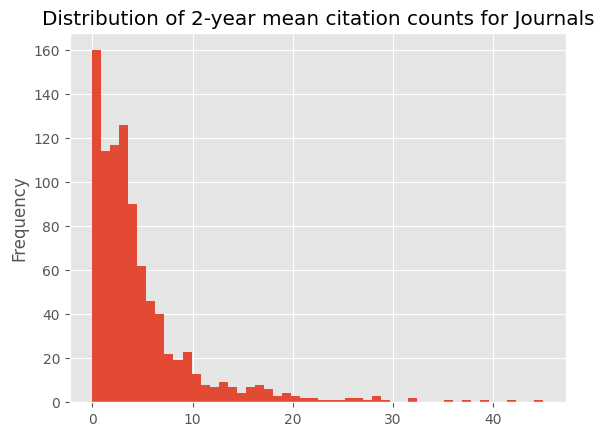

In [20]:
journal_level = papers_all.drop_duplicates(subset=["journals"], keep="first")
journal_level = journal_level.replace({"Error": np.nan, "Not Found": np.nan, "Unknown": np.nan})

plt.title("Distribution of h-indices for Journals")
plt.xlabel("h-index")
journal_level['journal_h_index'].dropna().astype(int).plot(kind="hist", bins=50)
plt.show()

plt.title("Distribution of i10-indices for Journals")
plt.xlabel("i10")
journal_level['journal_i10'].dropna().astype(int).plot(kind="hist", bins=50)
plt.show()

plt.title("Distribution of 2-year mean citation counts for Journals")
plt.xlabel("2-year mean citation counts")
journal_level['two_year_mc'].dropna().astype(float).plot(kind="hist", bins=50)
plt.show()

In [15]:
journal_level.journal_h_index.value_counts()

journal_h_index
153    10
70      7
81      7
212     7
159     7
       ..
252     1
296     1
417     1
155     1
208     1
Name: count, Length: 430, dtype: int64